<a href="https://colab.research.google.com/github/xabierblanch/EGG_FotogrametriaTerrestre/blob/main/FTM_01_Calibracio_camera_OpenCV_ChArUco.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Calibració de càmera amb OpenCV i ChArUco

En aquesta pràctica calibraràs la càmera del teu telèfon mòbil a partir de diverses fotografies d’un patró **ChArUco**.

L’objectiu és obtenir:
- la **matriu intrínseca** de la càmera;
- els **coeficients de distorsió**;
- l’**error de reprojecció (RMSE)**;
- i una versió **corregida de la distorsió** d’una imatge.


## 1. Patrons de calibratge

Hi ha diferents opcions per proporcionar punts de coordenades conegudes.

### Chessboard tradicional

Un patró de quadrícula de blancs i negres. Les cantonades dels quadrats es detecten automàticament i la seva geometria és coneguda.

**Avantatges:** senzill i clàssic.

**Limitacions:** és convenient que una part important del patró sigui visible i que les cantonades es puguin detectar correctament.

### ChArUco

Combina:
- la geometria de les cantonades d’un **chessboard**;
- la identificació robusta dels marcadors **ArUco**.

Les cantonades ChArUco són especialment adequades per a calibratge i, segons la documentació actual d’OpenCV, es recomanen davant de les cantonades dels marcadors ArUco per a aquest ús.

A més, es poden utilitzar vistes parcials del patró i no cal que totes les cantonades siguin visibles en totes les fotografies.

![Descripció de la imatge](https://gregorkovalcik.github.io/opencv_contrib/charucodefinition.png)


## 2. Com hem d’adquirir les fotografies?

Farem diverses fotografies del patró des de **posicions i orientacions diferents**

![Descripció de la imatge](https://www.mathworks.com/help/vision/ug/cameracalibrator_fov2.png)

**Recomanacions**

- Utilitza el **mateix telèfon i la mateixa càmera** durant tota la pràctica.
- No utilitzis zoom digital.
- Si és possible, utilitza la càmera principal i evita canviar d’objectiu entre fotografies.
- Mantén el patró **pla i rígid**.
- Omple una part important del camp de visió, però no cal que el patró ocupi sempre tota la imatge.
- Fes fotografies amb el patró:
  - centrat;
  - desplaçat cap a les vores;
  - inclinat horitzontalment i verticalment;
  - a diferents distàncies.
- Evita fotografies mogudes, desenfocades o amb reflexos.
- Procura tenir aproximadament **15–25 fotografies útils**.

**Important:** no cal que totes les fotografies siguin perfectes ni que mostrin tot el patró. La diversitat de vistes és important.

## 3. Instal·lem OpenCV


In [62]:

# Instal·lem OpenCV amb el mòdul ArUco/ChArUco.
!pip -q install -U opencv-contrib-python-headless


In [63]:

import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("OpenCV:", cv2.__version__)
print("Mòdul aruco disponible:", hasattr(cv2, "aruco"))


OpenCV: 5.0.0
Mòdul aruco disponible: True


## 4. Crear el patró ChArUco

El patró té una geometria coneguda. En aquest exemple:

- **11 × 8 quadrats**
- costat del quadrat: **30 mm**
- costat del marcador ArUco: **20 mm**

Les dimensions físiques són importants perquè defineixen l’escala del sistema de coordenades del patró.


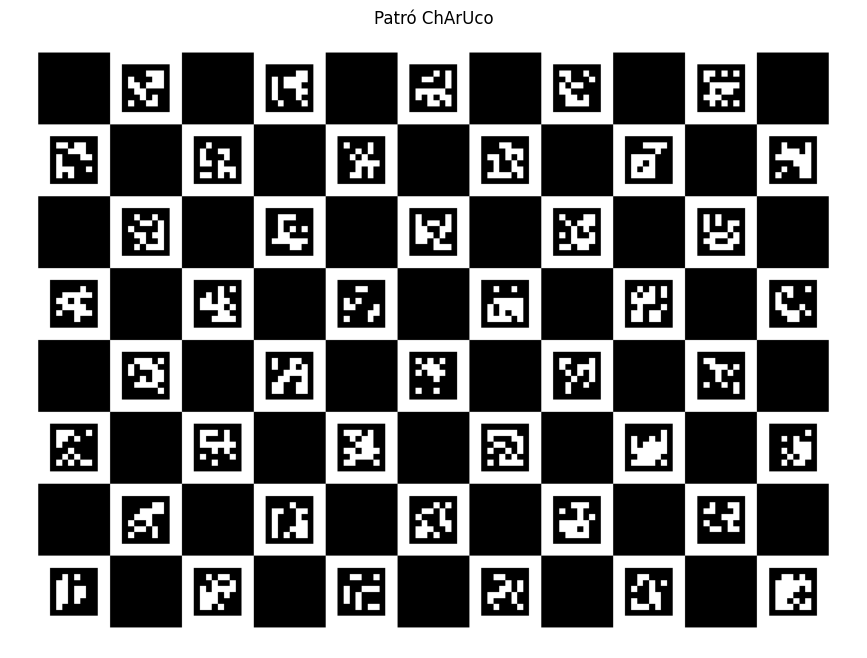

Patró desat com: charuco_board.png


In [64]:

# Definim la geometria del patró.
squares_x = 11
squares_y = 8
square_length = 30.0   # mm
marker_length = 20.0   # mm

# Diccionari de marcadors ArUco.
dictionary = cv2.aruco.getPredefinedDictionary(
    cv2.aruco.DICT_6X6_250
)

# Creem el tauler ChArUco.
board = cv2.aruco.CharucoBoard(
    (squares_x, squares_y),
    square_length,
    marker_length,
    dictionary
)

# Generem una imatge del patró.
board_image = board.generateImage((1650, 1200), marginSize=40, borderBits=1)

plt.figure(figsize=(12, 8))
plt.imshow(board_image, cmap="gray")
plt.axis("off")
plt.title("Patró ChArUco")
plt.show()

# Guardem el patró per poder-lo imprimir.
cv2.imwrite("charuco_board.png", board_image)
print("Patró desat com: charuco_board.png")


## 5. Carregar les fotografies

Ara pujarem les fotografies fetes amb el telèfon.

**Abans de continuar:** selecciona totes les fotografies que vulguis utilitzar per a la calibració.


In [65]:
from google.colab import files
from pathlib import Path

# ============================================================
# ELIMINAR IMATGES ANTERIORS
# ============================================================

# Eliminem les imatges JPG i JPEG existents
for p in Path(".").glob("*.jpg"):
    p.unlink()

for p in Path(".").glob("*.jpeg"):
    p.unlink()

print("Imatges anteriors eliminades.")

# ============================================================
# CARREGAR NOVES IMATGES
# ============================================================

uploaded = files.upload()

image_paths = sorted([Path(name) for name in uploaded.keys()])

print(f"\nImatges carregades: {len(image_paths)}")

for p in image_paths:
    print(" -", p.name)


Imatges anteriors eliminades.


Saving 1788954385421.jpg to 1788954385421.jpg
Saving 1788954385443.jpg to 1788954385443.jpg
Saving 1788954385478.jpg to 1788954385478.jpg
Saving 1788954385509.jpg to 1788954385509.jpg
Saving 1788954385527.jpg to 1788954385527.jpg
Saving 1788954385542.jpg to 1788954385542.jpg
Saving 1788954385564.jpg to 1788954385564.jpg
Saving 1788954385584.jpg to 1788954385584.jpg
Saving 1788954385604.jpg to 1788954385604.jpg
Saving 1788954385622.jpg to 1788954385622.jpg
Saving 1788954385639.jpg to 1788954385639.jpg
Saving 1788954385658.jpg to 1788954385658.jpg
Saving 1788954385675.jpg to 1788954385675.jpg
Saving 1788954385691.jpg to 1788954385691.jpg
Saving 1788954385706.jpg to 1788954385706.jpg
Saving 1788954385726.jpg to 1788954385726.jpg
Saving 1788954385743.jpg to 1788954385743.jpg
Saving 1788954385761.jpg to 1788954385761.jpg
Saving 1788954385778.jpg to 1788954385778.jpg
Saving 1788954385795.jpg to 1788954385795.jpg
Saving 1788954385816.jpg to 1788954385816.jpg
Saving 1788954385839.jpg to 178895


## 6. Detectar les cantonades ChArUco

OpenCV fa dues coses principals:

1. detecta els **marcadors ArUco**;
2. a partir d’aquests, determina les **cantonades ChArUco** i els seus identificadors.

Això ens permet saber quina cantonada del patró correspon a cada punt detectat a la imatge.


In [85]:
# Paràmetres del detector ArUco. Activem el refinament subpíxel de les
# cantonades: millora notablement la precisió de la detecció i, per tant,
# baixa el RMSE final del calibratge.
detector_params = cv2.aruco.DetectorParameters()
detector_params.cornerRefinementMethod = cv2.aruco.CORNER_REFINE_SUBPIX

charuco_params = cv2.aruco.CharucoParameters()

# Creem el detector ChArUco amb aquests paràmetres.
charuco_detector = cv2.aruco.CharucoDetector(
    board, charuco_params, detector_params
)

# Nombre mínim de cantonades ChArUco per acceptar una vista.
MIN_CORNERS_PER_VIEW = 6

all_charuco_corners = []
all_charuco_ids = []
all_object_points = []
all_image_points = []
used_image_paths = []

image_size = None
detection_images = []

for image_path in image_paths:

    image = cv2.imread(str(image_path))

    if image is None:
        print(f"No s'ha pogut llegir: {image_path.name}")
        continue

    current_size = (image.shape[1], image.shape[0])

    # Totes les fotografies han de tenir la mateixa resolució.
    if image_size is None:
        image_size = current_size

    elif current_size != image_size:
        print(
            f"{image_path.name}: descartada, resolució {current_size} "
            f"diferent de la resta ({image_size})"
        )
        image_path.unlink()
        continue

    # Detectem les cantonades ChArUco i els seus identificadors.
    charuco_corners, charuco_ids, marker_corners, marker_ids = (
        charuco_detector.detectBoard(image)
    )

    n = 0 if charuco_ids is None else len(charuco_ids)

    print(f"{image_path.name}: {n} cantonades ChArUco detectades")

    # Descartem i eliminem les fotografies amb poques cantonades.
    if charuco_ids is None or len(charuco_ids) < MIN_CORNERS_PER_VIEW:
        print(
            f"  -> Vista descartada i eliminada: menys de "
            f"{MIN_CORNERS_PER_VIEW} cantonades."
        )
        image_path.unlink()
        continue

    # Relacionem els punts 2D de la imatge amb les coordenades 3D
    # corresponents del patró.
    object_points, image_points = board.matchImagePoints(
        charuco_corners, charuco_ids
    )

    all_object_points.append(object_points)
    all_image_points.append(image_points)
    all_charuco_corners.append(charuco_corners)
    all_charuco_ids.append(charuco_ids)
    used_image_paths.append(image_path)

    # Dibuixem les deteccions per inspeccionar-les.
    vis = image.copy()

    cv2.aruco.drawDetectedMarkers(
        vis, marker_corners, marker_ids
    )

    # Forcem la forma esperada per evitar problemes entre versions
    # d'OpenCV.
    charuco_corners_draw = np.asarray(
        charuco_corners, dtype=np.float32
    ).reshape(-1, 1, 2)

    charuco_ids_draw = np.asarray(
        charuco_ids, dtype=np.int32
    ).reshape(-1, 1)

    cv2.aruco.drawDetectedCornersCharuco(
        vis,
        charuco_corners_draw,
        charuco_ids_draw
    )

    detection_images.append(
        (
            image_path.name,
            cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)
        )
    )

# A partir d'ara, image_paths només conté les fotografies utilitzades.
image_paths = used_image_paths

print()
print(f"Vistes vàlides: {len(image_paths)}")

1788954385421.jpg: 70 cantonades ChArUco detectades
1788954385443.jpg: 0 cantonades ChArUco detectades
  -> Vista descartada i eliminada: menys de 6 cantonades.
1788954385478.jpg: 0 cantonades ChArUco detectades
  -> Vista descartada i eliminada: menys de 6 cantonades.
1788954385509.jpg: 70 cantonades ChArUco detectades
1788954385527.jpg: 0 cantonades ChArUco detectades
  -> Vista descartada i eliminada: menys de 6 cantonades.
1788954385542.jpg: 48 cantonades ChArUco detectades
1788954385564.jpg: 38 cantonades ChArUco detectades
1788954385584.jpg: 0 cantonades ChArUco detectades
  -> Vista descartada i eliminada: menys de 6 cantonades.
1788954385604.jpg: 0 cantonades ChArUco detectades
  -> Vista descartada i eliminada: menys de 6 cantonades.
1788954385622.jpg: 0 cantonades ChArUco detectades
  -> Vista descartada i eliminada: menys de 6 cantonades.
1788954385639.jpg: 0 cantonades ChArUco detectades
  -> Vista descartada i eliminada: menys de 6 cantonades.
1788954385658.jpg: 3 cantonad

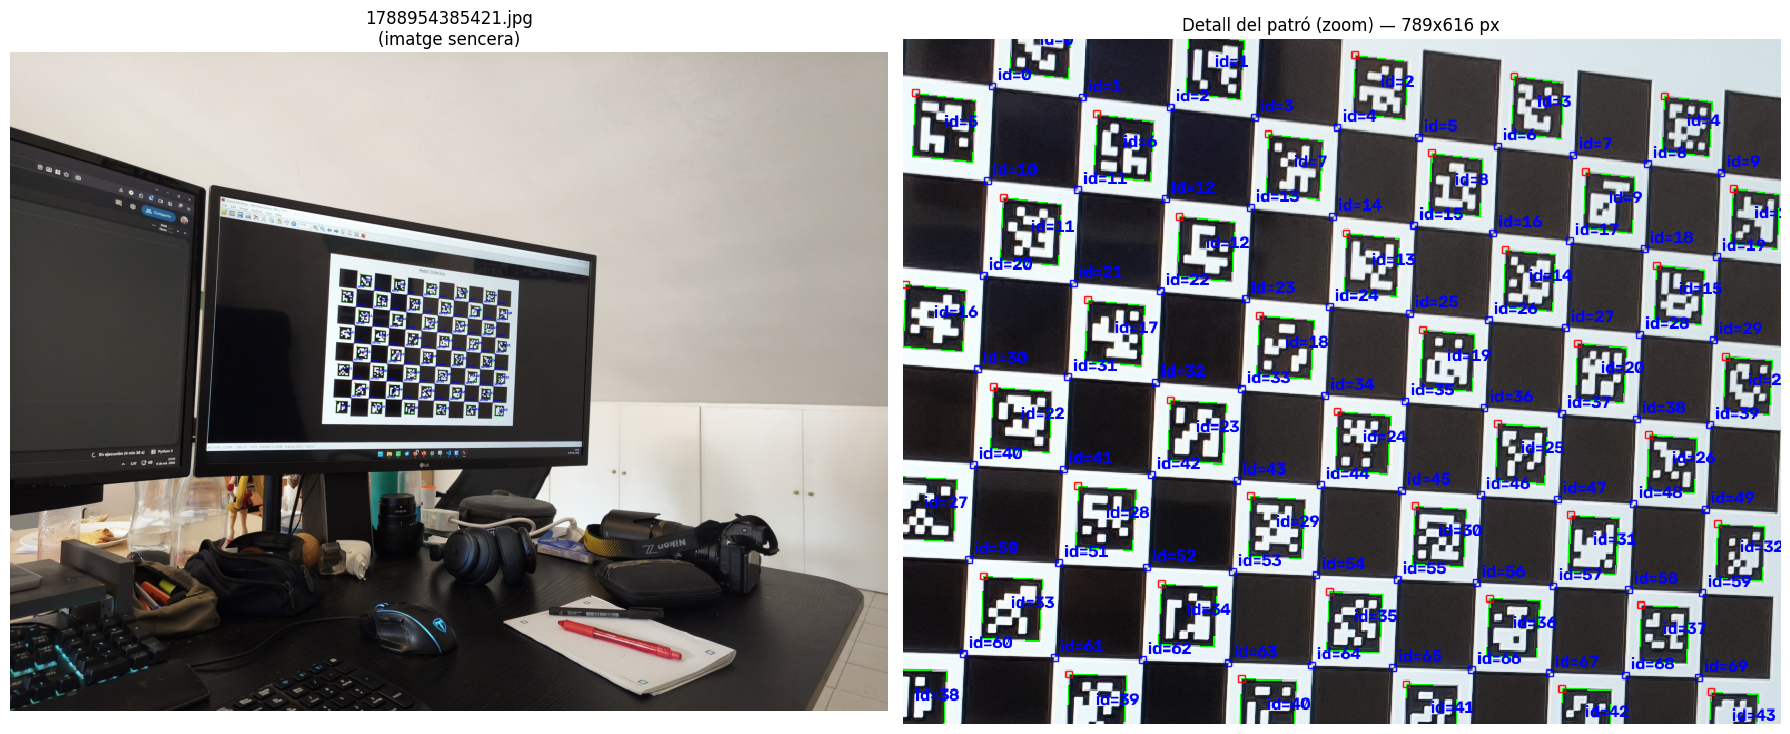

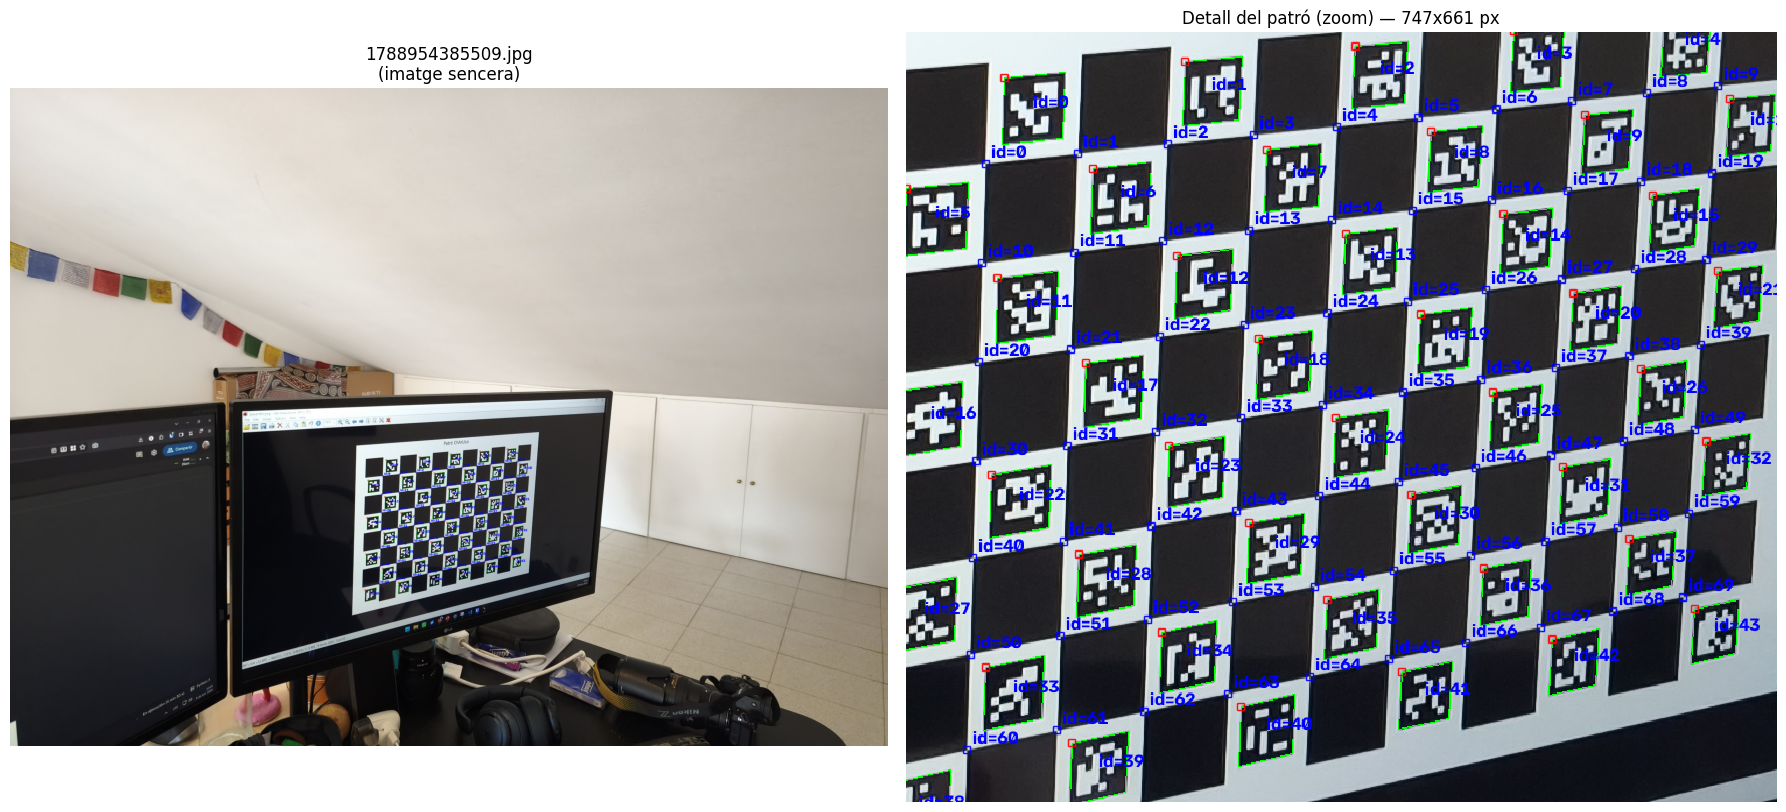

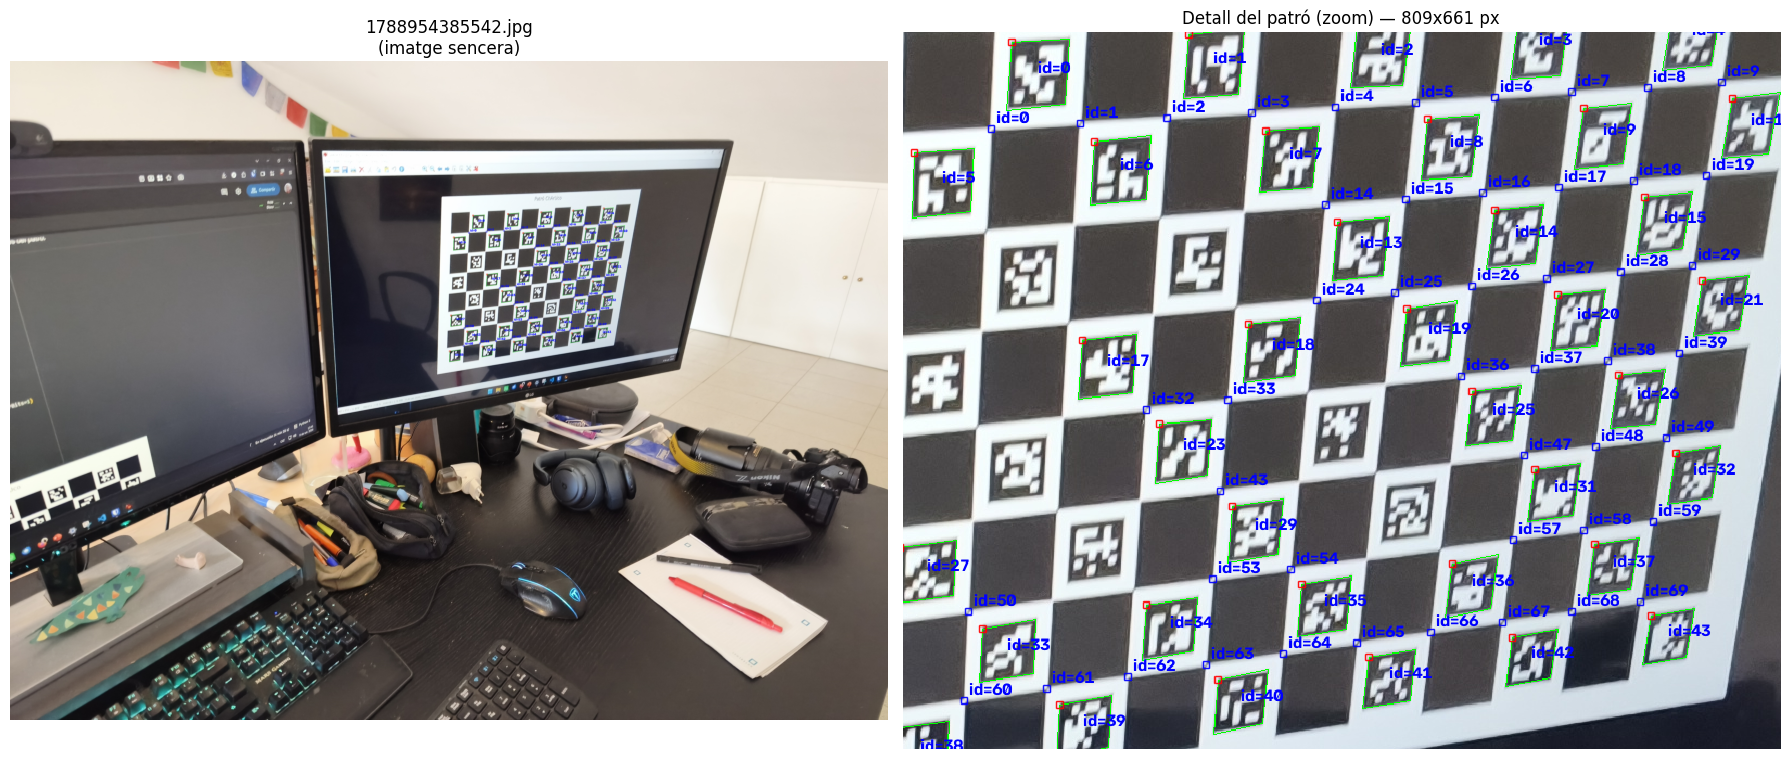

In [86]:
n_show = min(3, len(detection_images))
MARGIN_RATIO = 0.08

if n_show == 0:
    print("No hi ha vistes vàlides.")
else:
    for (name, vis), charuco_corners in zip(
        detection_images[:n_show], all_charuco_corners[:n_show]
    ):
        h, w = vis.shape[:2]

        # Calculem el requadre que engloba totes les cantonades detectades.
        pts = np.asarray(charuco_corners, dtype=np.float32).reshape(-1, 2)
        x_min, y_min = pts.min(axis=0)
        x_max, y_max = pts.max(axis=0)

        box_w = x_max - x_min
        box_h = y_max - y_min
        margin_x = box_w * MARGIN_RATIO
        margin_y = box_h * MARGIN_RATIO

        x0 = max(int(x_min - margin_x), 0)
        y0 = max(int(y_min - margin_y), 0)
        x1 = min(int(x_max + margin_x), w)
        y1 = min(int(y_max + margin_y), h)

        crop = vis[y0:y1, x0:x1]

        fig, axes = plt.subplots(1, 2, figsize=(18, 8))

        axes[0].imshow(vis)
        axes[0].set_title(f"{name}\n(imatge sencera)")
        axes[0].axis("off")

        # interpolation="nearest" evita que matplotlib suavitzi (difumini)
        # el retall en ampliar-lo, i així es veuen bé els píxels reals de
        # les cantonades detectades.
        axes[1].imshow(crop, interpolation="nearest")
        axes[1].set_title(f"Detall del patró (zoom) — {crop.shape[1]}x{crop.shape[0]} px")
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()



## 7. Comprovació de la detecció



In [87]:
# Coordenades 3D de les cantonades ChArUco del patró
object_points = board.getChessboardCorners()
print("Coordenades X, Y, Z")
print(f"Nombre de cantonades: {len(object_points)}")
for i, point in enumerate(object_points[:10]):
    print(f"Punt {i}: X={point[0]:.1f} mm, "
          f"Y={point[1]:.1f} mm, Z={point[2]:.1f} mm")

# Detectem les cantonades ChArUco d'una imatge (Es pot canviar la imatge)
image = cv2.imread(str(image_paths[0]))

charuco_corners, charuco_ids, marker_corners, marker_ids = (
    charuco_detector.detectBoard(image)
)

print("")
print("Coordenades u, v")
print(f"Cantonades detectades: {len(charuco_corners)}")
# Convertim les cantonades a una matriu de mida (N, 2)
corners_2d = charuco_corners.reshape(-1, 2)

# Mostrem les primeres coordenades
for point, idx in zip(corners_2d[:10], charuco_ids[:10]):
    u, v = point
    print(f"Punt {int(idx)}: u={u:.1f} px, v={v:.1f} px")

Coordenades X, Y, Z
Nombre de cantonades: 70
Punt 0: X=30.0 mm, Y=30.0 mm, Z=0.0 mm
Punt 1: X=60.0 mm, Y=30.0 mm, Z=0.0 mm
Punt 2: X=90.0 mm, Y=30.0 mm, Z=0.0 mm
Punt 3: X=120.0 mm, Y=30.0 mm, Z=0.0 mm
Punt 4: X=150.0 mm, Y=30.0 mm, Z=0.0 mm
Punt 5: X=180.0 mm, Y=30.0 mm, Z=0.0 mm
Punt 6: X=210.0 mm, Y=30.0 mm, Z=0.0 mm
Punt 7: X=240.0 mm, Y=30.0 mm, Z=0.0 mm
Punt 8: X=270.0 mm, Y=30.0 mm, Z=0.0 mm
Punt 9: X=300.0 mm, Y=30.0 mm, Z=0.0 mm

Coordenades u, v
Cantonades detectades: 70
Punt 0: u=1617.4 px, v=1103.1 px
Punt 1: u=1698.2 px, v=1112.8 px
Punt 2: u=1776.7 px, v=1122.0 px
Punt 3: u=1853.0 px, v=1131.2 px
Punt 4: u=1927.4 px, v=1140.0 px
Punt 5: u=1999.9 px, v=1148.6 px
Punt 6: u=2070.5 px, v=1157.1 px
Punt 7: u=2139.3 px, v=1165.4 px
Punt 8: u=2206.4 px, v=1173.2 px
Punt 9: u=2271.8 px, v=1181.0 px



## 8. Calibrar la càmera

Ara tenim:

- coordenades 3D conegudes del patró;
- coordenades 2D observades a cada fotografia;
- diverses vistes de la càmera.

OpenCV ajustarà els paràmetres de la càmera mitjançant un procés d’optimització basat en l’error de reprojecció.

El resultat principal és:

\begin{bmatrix}
f_x & 0 & c_x\\
0 & f_y & c_y\\
0 & 0 & 1
\end{bmatrix}

i els coeficients de distorsió.

\begin{bmatrix}
k_1 & k_2 & k3 & p_1 & p_2
\end{bmatrix}


In [88]:
# Comprovem que tenim prou dades abans de calibrar.
if len(all_image_points) < 5:
    raise RuntimeError(
        "Es recomanen més vistes. Intenta obtenir almenys 10–15 "
        "fotografies útils."
    )

# Convertim les dades al format esperat per OpenCV.
object_points_cv = [
    np.asarray(p, dtype=np.float32) for p in all_object_points
]
image_points_cv = [
    np.asarray(p, dtype=np.float32) for p in all_image_points
]

# Matriu intrínseca inicial desconeguda.
camera_matrix = np.zeros((3, 3), dtype=np.float64)

# Coeficients de distorsió inicials.
dist_coeffs = np.zeros((5, 1), dtype=np.float64)

# Calibratge.
rms, camera_matrix, dist_coeffs, rvecs, tvecs = cv2.calibrateCamera(
    object_points_cv,
    image_points_cv,
    image_size,
    camera_matrix,
    dist_coeffs
)

print("RMSE retornat per OpenCV:", rms, "píxels")
print()
print("Matriu intrínseca K:")
print(camera_matrix)
print()
print("Coeficients de distorsió:")
print(dist_coeffs.ravel())

print(f"RMSE = {rms:.3f} píxels")
print()

print("PARÀMETRES INTRÍNSECS")
print(f"Fx = {camera_matrix[0, 0]:.2f} píxels")
print(f"Fy = {camera_matrix[1, 1]:.2f} píxels")
print(f"Cx = {camera_matrix[0, 2]:.2f} píxels")
print(f"Cy = {camera_matrix[1, 2]:.2f} píxels")

print()
print("COEFICIENTS DE DISTORSIÓ")

print(f"k1 = {dist_coeffs[0, 0]:.8f}")
print(f"k2 = {dist_coeffs[1, 0]:.8f}")
print(f"p1 = {dist_coeffs[2, 0]:.8f}")
print(f"p2 = {dist_coeffs[3, 0]:.8f}")
print(f"k3 = {dist_coeffs[4, 0]:.8f}")

RMSE retornat per OpenCV: 0.5003595517577271 píxels

Matriu intrínseca K:
[[2.69483146e+03 0.00000000e+00 2.03122589e+03]
 [0.00000000e+00 2.69990954e+03 1.52714839e+03]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]

Coeficients de distorsió:
[ 0.05938017 -0.0121526   0.0008994  -0.00037325 -0.04841592]
RMSE = 0.500 píxels

PARÀMETRES INTRÍNSECS
Fx = 2694.83 píxels
Fy = 2699.91 píxels
Cx = 2031.23 píxels
Cy = 1527.15 píxels

COEFICIENTS DE DISTORSIÓ
k1 = 0.05938017
k2 = -0.01215260
p1 = 0.00089940
p2 = -0.00037325
k3 = -0.04841592


## 9. Anàlisi del resultats (Central Points)

In [89]:
# ============================================================
# COMPARACIÓ AMB EL CENTRE GEOMÈTRIC DE LA IMATGE
# ============================================================

# Resolució de la imatge
width, height = image_size

# Centre geomètric teòric
cx_teoric = width / 2
cy_teoric = height / 2

# Punt principal estimat per la calibració
cx_calibrat = camera_matrix[0, 2]
cy_calibrat = camera_matrix[1, 2]

# Diferències
delta_cx = cx_calibrat - cx_teoric
delta_cy = cy_calibrat - cy_teoric

# Distància entre els dos punts
distancia = np.sqrt(delta_cx**2 + delta_cy**2)

print("RESOLUCIÓ DE LA IMATGE")
print("----------------------")
print(f"Amplada: {width} px")
print(f"Alçada:  {height} px")

print()
print("CENTRE GEOMÈTRIC TEÒRIC")
print("------------------------")
print(f"Cx = {cx_teoric:.2f} px")
print(f"Cy = {cy_teoric:.2f} px")

print()
print("PUNT PRINCIPAL CALIBRAT")
print("------------------------")
print(f"Cx = {cx_calibrat:.2f} px")
print(f"Cy = {cy_calibrat:.2f} px")

print()
print("DIFERÈNCIA")
print("----------")
print(f"ΔCx = {delta_cx:+.2f} px")
print(f"ΔCy = {delta_cy:+.2f} px")
print(f"Distància = {distancia:.2f} px")

RESOLUCIÓ DE LA IMATGE
----------------------
Amplada: 4096 px
Alçada:  3072 px

CENTRE GEOMÈTRIC TEÒRIC
------------------------
Cx = 2048.00 px
Cy = 1536.00 px

PUNT PRINCIPAL CALIBRAT
------------------------
Cx = 2031.23 px
Cy = 1527.15 px

DIFERÈNCIA
----------
ΔCx = -16.77 px
ΔCy = -8.85 px
Distància = 18.97 px


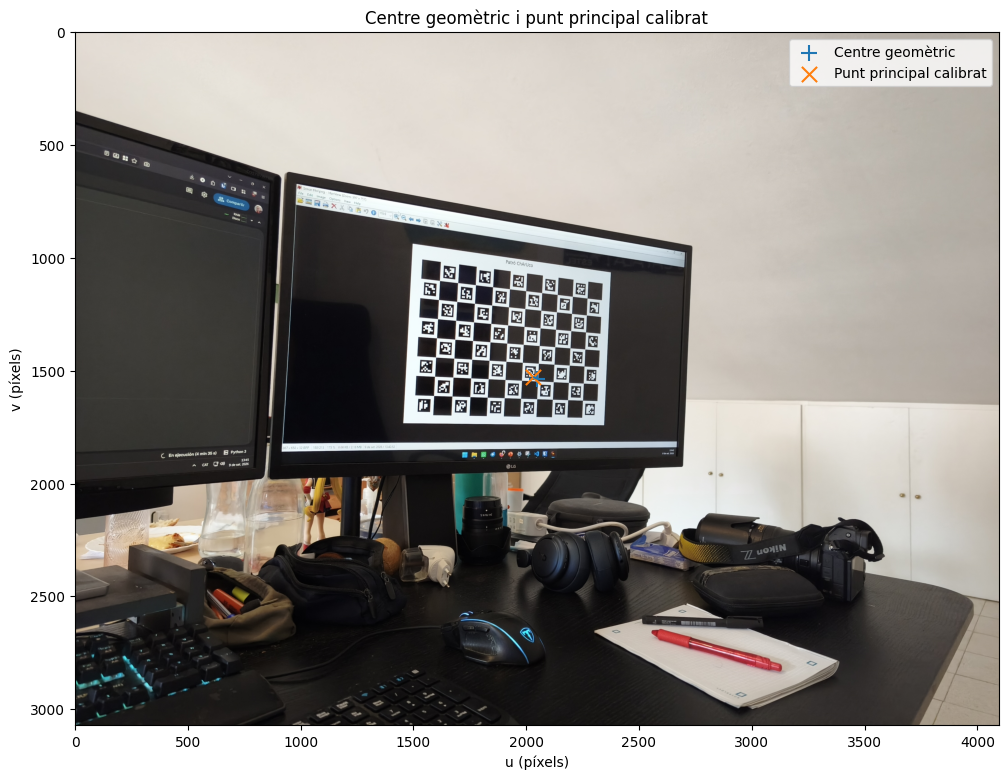

In [90]:
# ============================================================
# VISUALITZACIÓ DEL CENTRE I DEL PUNT PRINCIPAL
# ============================================================

image = cv2.imread(str(image_paths[0]))
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 9))
plt.imshow(image_rgb)

# Centre geomètric
plt.scatter(
    cx_teoric, cy_teoric,
    s=120,
    marker="+",
    label="Centre geomètric"
)

# Punt principal calibrat
plt.scatter(
    cx_calibrat, cy_calibrat,
    s=120,
    marker="x",
    label="Punt principal calibrat"
)

plt.plot(
    [cx_teoric, cx_calibrat],
    [cy_teoric, cy_calibrat],
    linestyle="--"
)

plt.legend()
plt.xlabel("u (píxels)")
plt.ylabel("v (píxels)")
plt.title("Centre geomètric i punt principal calibrat")
plt.show()

In [91]:
# ============================================================
# FOCAL FÍSICA I EQUIVALENT A 35 mm
# ============================================================

### BUSQUEU A INTERNET AQUEST PARÀMETRE
sensor_width_mm = 8.29
sensor_height_mm = 6.22
###########

if sensor_width_mm is not None and sensor_height_mm is not None:

    # Focal física
    focal_x_mm = fx * sensor_width_mm / width
    focal_y_mm = fy * sensor_height_mm / height

    # Diagonal del sensor
    sensor_diagonal_mm = np.sqrt(
        sensor_width_mm**2 + sensor_height_mm**2
    )

    # Factor de crop respecte al format 35 mm
    diagonal_35mm = np.sqrt(36**2 + 24**2)
    crop_factor = diagonal_35mm / sensor_diagonal_mm

    # Focal equivalent a 35 mm
    focal_35mm = focal_x_mm * crop_factor

    print("CÀLCUL DE LA FOCAL")
    print(f"Focal física X:       {focal_x_mm:.2f} mm")
    print(f"Focal física Y:       {focal_y_mm:.2f} mm")
    print(f"Diagonal del sensor:  {sensor_diagonal_mm:.2f} mm")
    print(f"Factor de crop:       {crop_factor:.2f}×")
    print(f"Focal equivalent:     {focal_35mm:.2f} mm")

else:
    print("No s'han especificat les dimensions del sensor.")

CÀLCUL DE LA FOCAL
Focal física X:       5.45 mm
Focal física Y:       5.47 mm
Diagonal del sensor:  10.36 mm
Factor de crop:       4.17×
Focal equivalent:     22.77 mm



## 10. Error de reprojecció

Recordem:

$$
e_i =
\sqrt{
(u_i-\hat{u}_i)^2 +
(v_i-\hat{v}_i)^2
}
$$


La calibració intenta reduir aquests errors.

El valor global que utilitzarem és:

$$
RMSE =
\sqrt{
\frac{1}{N}
\sum_{i=1}^{N} e_i^2
}
$$

**Unitats: píxels**

Un RMSE més petit indica, en general, un millor ajust del model a les observacions.

**Però:** un RMSE baix no garanteix per si sol que la calibració sigui bona. També hem d’inspeccionar la distribució dels errors, la geometria de les vistes i la qualitat de les deteccions.


In [92]:
# ============================================================
# ERROR DE REPROJECCIÓ PER A CADA FOTOGRAFIA
# ============================================================

per_view_rmse = []
per_view_points = []

for obj, img, rvec, tvec in zip(
    object_points_cv,
    image_points_cv,
    rvecs,
    tvecs
):
    # Projectem els punts 3D sobre la imatge
    projected, _ = cv2.projectPoints(
        obj, rvec, tvec, camera_matrix, dist_coeffs
    )

    projected = projected.reshape(-1, 2)
    observed = img.reshape(-1, 2)

    # Error de reprojecció de cada punt
    errors = np.linalg.norm(observed - projected, axis=1)

    # RMSE de la fotografia
    rmse_view = np.sqrt(np.mean(errors**2))

    per_view_rmse.append(rmse_view)
    per_view_points.append(len(errors))


per_view_rmse = np.array(per_view_rmse)
per_view_points = np.array(per_view_points)


# ============================================================
# ESTADÍSTIQUES GLOBALS
# ============================================================

total_points = per_view_points.sum()

print("ESTADÍSTIQUES DE LA CALIBRACIÓ")
print("------------------------------")
print(f"Fotografies utilitzades: {len(per_view_rmse)}")
print(f"Nombre total de punts:   {total_points}")
print(f"RMSE global:             {rms:.3f} píxels")
print(f"RMSE mitjà per vista:    {per_view_rmse.mean():.3f} píxels")
print(f"Millor vista:            {per_view_rmse.min():.3f} píxels")
print(f"Pitjor vista:            {per_view_rmse.max():.3f} píxels")
print(f"Punts per vista (mitjana): {per_view_points.mean():.1f}")


# ============================================================
# DETALL DE CADA FOTOGRAFIA
# ============================================================

print()
print("RESULTATS PER FOTOGRAFIA")
print("------------------------")
print(f"{'Fotografia':20s} {'Punts':>8s} {'RMSE (px)':>12s}")

for i, (rmse_view, n_points) in enumerate(
    zip(per_view_rmse, per_view_points)
):
    print(
        f"{image_paths[i].name:20s} "
        f"{n_points:8d} "
        f"{rmse_view:12.3f}"
    )


ESTADÍSTIQUES DE LA CALIBRACIÓ
------------------------------
Fotografies utilitzades: 27
Nombre total de punts:   1562
RMSE global:             0.500 píxels
RMSE mitjà per vista:    0.476 píxels
Millor vista:            0.251 píxels
Pitjor vista:            1.188 píxels
Punts per vista (mitjana): 57.9

RESULTATS PER FOTOGRAFIA
------------------------
Fotografia              Punts    RMSE (px)
1788954385421.jpg          70        0.436
1788954385509.jpg          70        0.335
1788954385542.jpg          48        0.336
1788954385564.jpg          38        0.321
1788954385675.jpg          50        0.333
1788954385691.jpg          70        0.412
1788954385706.jpg          70        0.396
1788954385726.jpg          70        0.495
1788954385743.jpg          70        0.553
1788954385761.jpg          70        0.474
1788954385778.jpg          65        0.375
1788954385795.jpg          11        0.365
1788954385816.jpg          18        0.403
1788954385894.jpg          62        0.833


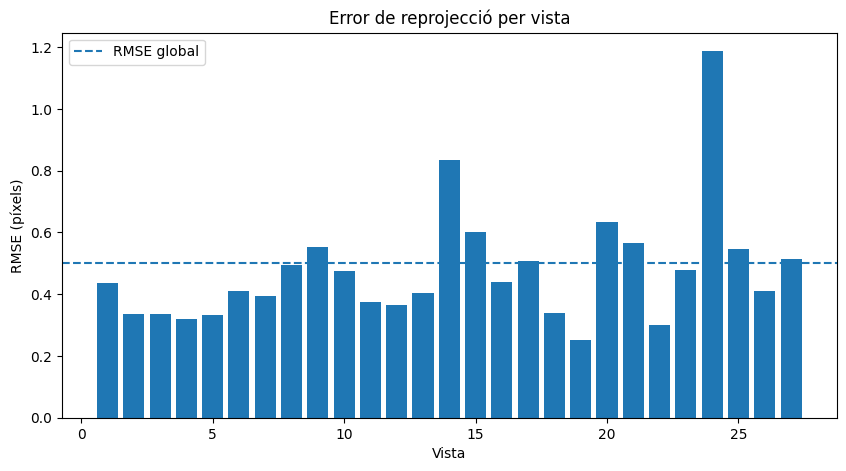

In [94]:

# Representem l'error de reprojecció de cada fotografia.
plt.figure(figsize=(10, 5))
plt.bar(range(1, len(per_view_rmse) + 1), per_view_rmse)
plt.axhline(rms, linestyle="--", label="RMSE global")
plt.xlabel("Vista")
plt.ylabel("RMSE (píxels)")
plt.title("Error de reprojecció per vista")
plt.legend()
plt.show()


## 11. Corregir la distorsió (Undistort)

Ara que tenim els paràmetres de calibratge, podem aplicar-los a una imatge .

La idea és:

$$
\text{Imatge amb distorsió}
\quad\xrightarrow{\text{paràmetres de calibratge}}\quad
\text{Imatge corregida}
$$

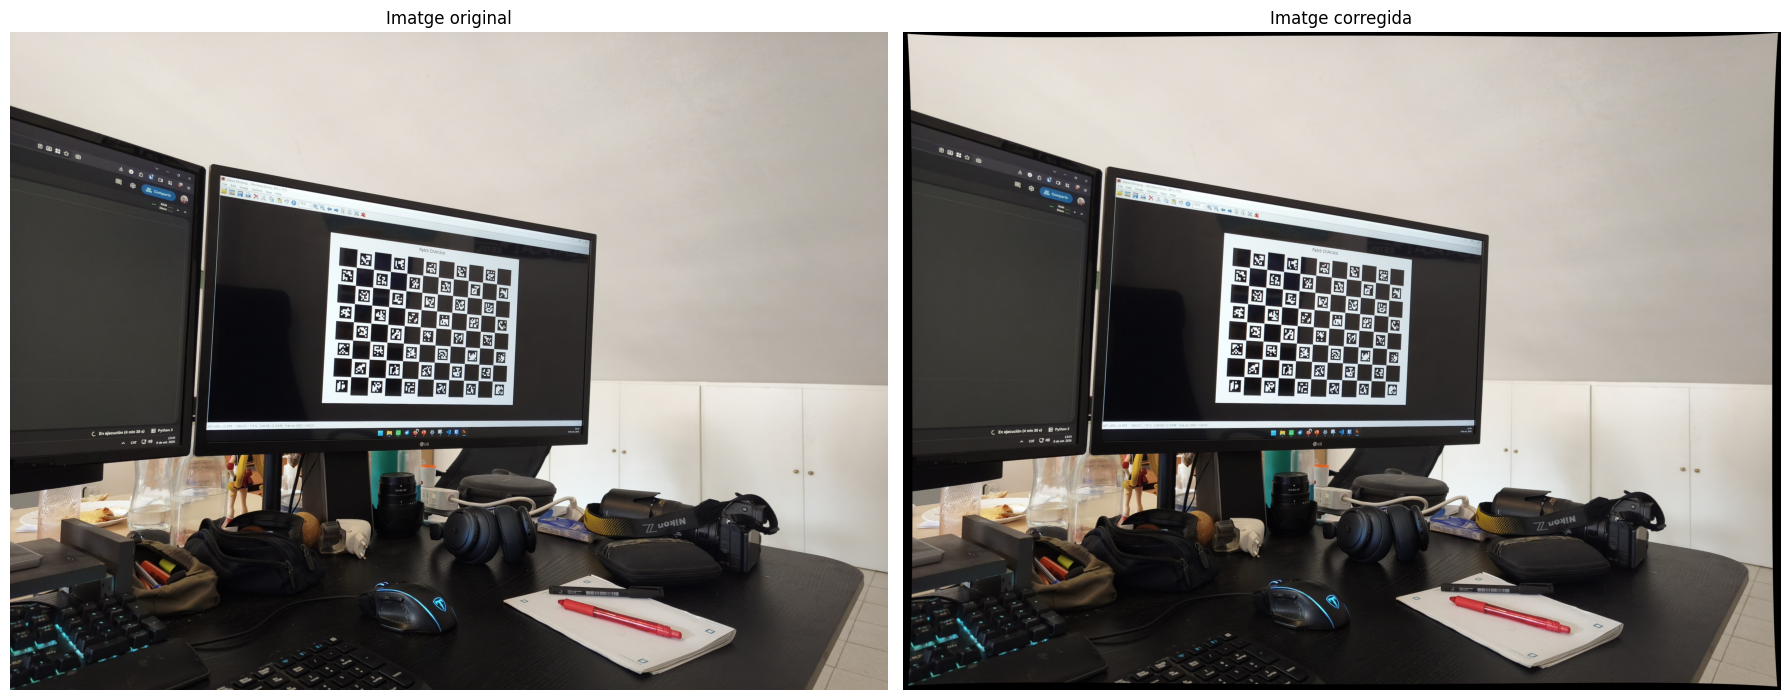

In [95]:
# Seleccionem una de les fotografies carregades.
test_path = image_paths[0]
test_image = cv2.imread(str(test_path))

# Corregim la distorsió.
undistorted = cv2.undistort(
    test_image,
    camera_matrix,
    dist_coeffs
)

# Convertim de BGR a RGB per mostrar amb matplotlib.
test_image_rgb = cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB)
undistorted_rgb = cv2.cvtColor(undistorted, cv2.COLOR_BGR2RGB)

# Mostrem original i corregida una al costat de l'altra.
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].imshow(test_image_rgb)
axes[0].set_title("Imatge original")
axes[0].axis("off")

axes[1].imshow(undistorted_rgb)
axes[1].set_title("Imatge corregida")
axes[1].axis("off")

plt.tight_layout()
plt.show()


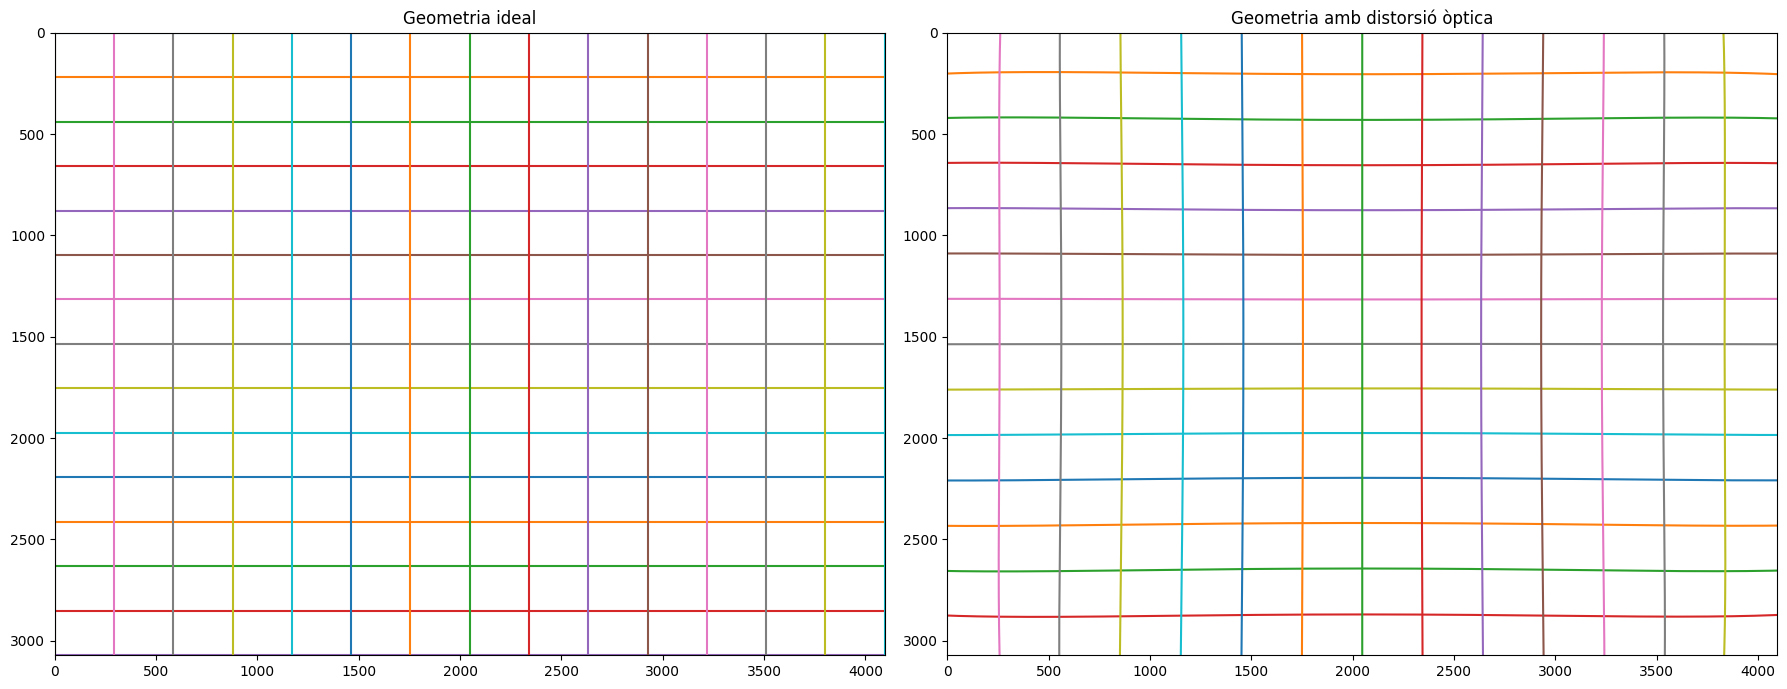

In [96]:
# ============================================================
# VISUALITZACIÓ DE LA DISTORSIÓ ÒPTICA
# ============================================================

height, width = test_image.shape[:2]
fx, fy = camera_matrix[0, 0], camera_matrix[1, 1]
cx, cy = camera_matrix[0, 2], camera_matrix[1, 2]
k1, k2, p1, p2, k3 = dist_coeffs.ravel()


def distort_points(points):
    """Aplica el model de distorsió radial i tangencial."""

    x = (points[:, 0] - cx) / fx
    y = (points[:, 1] - cy) / fy
    r2 = x**2 + y**2

    radial = 1 + k1*r2 + k2*r2**2 + k3*r2**3

    x_d = x*radial + 2*p1*x*y + p2*(r2 + 2*x**2)
    y_d = y*radial + p1*(r2 + 2*y**2) + 2*p2*x*y

    return np.column_stack((fx*x_d + cx, fy*y_d + cy))


# Quadrícula ideal
n_lines = 15
x_lines = np.linspace(0, width - 1, n_lines)
y_lines = np.linspace(0, height - 1, n_lines)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for y in y_lines:
    points = np.column_stack((
        np.linspace(0, width - 1, 500),
        np.full(500, y)
    ))
    axes[0].plot(*points.T)
    axes[1].plot(*distort_points(points).T)

for x in x_lines:
    points = np.column_stack((
        np.full(500, x),
        np.linspace(0, height - 1, 500)
    ))
    axes[0].plot(*points.T)
    axes[1].plot(*distort_points(points).T)

for ax, title in zip(axes, ["Geometria ideal",
                            "Geometria amb distorsió òptica"]):
    ax.set(title=title, xlim=(0, width), ylim=(height, 0))
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

## 12. Tancament de la pràctica

### Calibració amb la càmera gran angular

Repeteix el procediment de calibratge utilitzant ara la **càmera gran angular del teu mòbil**.

Has de:

1. Capturar una nova sèrie de fotografies del patró ChArUco amb la càmera gran angular.
2. Repetir el procés de detecció de les cantonades.
3. Calibrar la càmera amb OpenCV.
4. Obtenir els paràmetres intrínsecs i els coeficients de distorsió.
5. Calcular l'error de reprojecció.
6. Aplicar la correcció de la distorsió a una de les imatges.

**Abans de la propera sessió, lliura a Atenea:**

- la gràfica amb l'error de reprojecció per fotografia.
- una imatge original i la imatge corregida.
- les imatges amb la distorsió òptica.


L'objectiu és comparar el comportament de la càmera principal i de la càmera gran angular, especialment pel que fa a la **distorsió òptica** i a l'**error de reprojecció**.


### Recursos

Per consultar altres exemples de calibratge amb OpenCV:

- [OpenCV — Camera Calibration](https://docs.opencv.org/4.x/dc/dbb/tutorial_py_calibration.html)
- [OpenCV — Calibration with ChArUco boards](https://docs.opencv.org/4.x/da/d13/tutorial_aruco_calibration.html)

- [Roboflow — Vision AI Camera Calibration Guide](https://blog.roboflow.com/vision-ai-camera-calibration/)

- [Learn OpenCV — Camera Calibration using OpenCV](https://learnopencv.com/camera-calibration-using-opencv/)

- [MATLAB — What Is Camera Calibration?](https://www.mathworks.com/help/vision/ug/camera-calibration.html)

